In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("flight_price.csv")

In [6]:
df.shape

(9450, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9450 entries, 0 to 9449
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          9450 non-null   object 
 1   Source           9450 non-null   object 
 2   Destination      9450 non-null   object 
 3   Route            9449 non-null   object 
 4   Dep_Time         9450 non-null   object 
 5   Arrival_Time     9450 non-null   object 
 6   Duration         9450 non-null   object 
 7   Total_Stops      9250 non-null   object 
 8   Additional_Info  9450 non-null   object 
 9   Price            9450 non-null   int64  
 10  Month            9450 non-null   int64  
 11  WeekDay          9450 non-null   object 
 12  Day              9214 non-null   float64
dtypes: float64(1), int64(2), object(10)
memory usage: 959.9+ KB


In [8]:
df.head()


,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,WeekDay,Day
0,Jet Airways,Delhi,Banglore,DEL → BOM → COK,20:00,04:25 10 Jun,26h 35m,1 stop,In-flight meal not included,14924,6,Thursday,6.0
1,Jet Airways,Delhi,Cochin,DEL → BOM → COK,16:00,19:00 10 Jun,27h,1 stop,In-flight meal not included,10577,6,Sunday,9.0
2,Jet Airways,Mumbai,Hyderabad,BOM → HYD,19:35,21:05,1h 30m,non-stop,No info,5678,3,Friday,15.0
3,Multiple carriers,Delhi,Banglore,DEL → BOM → COK,18:55,01:30 16 Jun,15h 10m,1 stop,In-flight meal not included,7408,5,Monday,6.0
4,Air India,Delhi,Cochin,DEL → COK,17:10,17:55,8h 20m,non-stop,No info,6724,6,Monday,24.0


In [9]:
df.describe()

,Price,Month,Day
count,9450.000000,9450.000000,9214.000000
mean,9027.895556,4.718730,13.517582
std,4466.677471,1.162725,8.459792
min,1759.000000,3.000000,1.000000
25%,5198.000000,3.000000,6.000000
50%,8366.000000,5.000000,12.000000
75%,12373.000000,6.000000,21.000000
max,57209.000000,6.000000,27.000000


In [10]:
df['Price'].describe()

,Price
count,9450.000000
mean,9027.895556
std,4466.677471
min,1759.000000
25%,5198.000000
50%,8366.000000
75%,12373.000000
max,57209.000000


In [11]:
cols=['Destination','Airline','Source','Additional_Info','Total_Stops','Month','WeekDay','Day']
for col in cols:
    print(df[col].value_counts())

Destination
Cochin       4066
Banglore     2524
Delhi        1112
New Delhi     827
Hyderabad     599
Kolkata       322
Name: count, dtype: int64
Airline
Jet Airways                          3318
IndiGo                               1856
Air India                            1601
Multiple carriers                    1027
SpiceJet                              754
Vistara                               423
Air Asia                              261
GoAir                                 195
Multiple carriers Premium economy      12
Jet Airways Business                    2
Vistara Premium economy                 1
Name: count, dtype: int64
Source
Delhi       3958
Kolkata     2494
Banglore    2042
Mumbai       603
Chennai      353
Name: count, dtype: int64
Additional_Info
No info                         7375
In-flight meal not included     1750
No check-in baggage included     298
1 Long layover                    13
Change airports                    5
No Info                            3
2 

In [12]:
df.isnull().sum()

,0
Airline,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,200
Additional_Info,0
Price,0


In [13]:
df[df['Route'].isnull()]

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,WeekDay,Day
599,Air India,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480,5,Monday,6.0


In [14]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols=df.select_dtypes(include=np.number).columns

In [15]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Month',
       'WeekDay', 'Day'],
      dtype='object')

In [16]:
df.dropna(subset=['Route'],inplace=True)

Since only one row had a missing value for Route and it could not be reconstructed, it was dropped.

In [17]:
df.loc[df['Total_Stops'].isnull(),'Route'].head(10)

,Route
79,DEL → BOM → COK
105,BLR → DEL
134,DEL → BOM → COK
144,CCU → BLR
148,BLR → DEL
149,CCU → BOM → BLR
169,DEL → BOM → COK
191,BLR → BOM → DEL
200,DEL → IDR → BOM → COK
234,CCU → DEL → BLR


In [18]:
def get_total_stops(route):
  airports=route.split(' → ')
  stops=len(airports)-2
  if stops==0:
    return 'non-stop'
  elif stops==1:
    return '1 stop'
  else:
    return f"{stops} stops"

In [19]:
df.loc[df["Total_Stops"].isnull(),"Total_Stops"]=df.loc[df["Total_Stops"].isnull(),"Route"].apply(get_total_stops)

It was observed that the Total_Stops column could be inferred from the Route column. Therefore, the missing values in Total_Stops column were reconstructed using the corresponding Route column.

In [20]:
df[df['Day'].isnull()]

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Month,WeekDay,Day
85,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,07:00,16:10,9h 10m,1 stop,In-flight meal not included,9134,3,Friday,NaN
103,Air India,Kolkata,Banglore,CCU → BOM → GOI → BLR,09:25,05:35 10 Jun,20h 10m,2 stops,No info,11432,6,Sunday,NaN
219,Multiple carriers,Delhi,Banglore,DEL → IDR → BOM → COK,06:30,01:35 04 Mar,27h 35m,2 stops,No info,34503,5,Monday,NaN
270,Air India,Delhi,Cochin,DEL → NAG → BOM → COK,05:55,07:40 07 Mar,25h 45m,2 stops,No info,14641,3,Wednesday,NaN
304,IndiGo,Banglore,Delhi,BLR → DEL,16:55,19:55,3h,non-stop,No info,4823,6,Monday,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9375,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,06:40,09:30 07 Mar,27h 45m,1 stop,No info,17261,3,Friday,NaN
9380,Jet Airways,Mumbai,Hyderabad,BOM → HYD,19:35,21:05,1h 30m,non-stop,In-flight meal not included,3210,5,Tuesday,NaN
9394,Jet Airways,Kolkata,Banglore,CCU → BOM → BLR,16:30,19:50 02 Apr,27h 20m,1 stop,No info,12681,4,Monday,NaN
9400,IndiGo,Delhi,Cochin,DEL → BOM → COK,08:00,21:00,20h 25m,1 stop,In-flight meal not included,6794,6,Saturday,NaN


In [21]:
df['Day'].corr(df['Price'])

np.float64(-0.07565885594125601)

In [22]:
df[["Month", "Day", "WeekDay", "Dep_Time", "Arrival_Time", "Duration"]].sample(10, random_state=42)

,Month,Day,WeekDay,Dep_Time,Arrival_Time,Duration
3024,3,21.0,Thursday,09:10,12:00 02 Apr,6h 20m
5134,6,6.0,Thursday,10:30,22:50,5h 35m
762,6,12.0,Wednesday,13:15,14:45,1h 30m
1471,3,15.0,Friday,05:45,14:30,9h 30m
1047,3,27.0,Wednesday,06:05,09:25 28 Mar,27h 20m
4330,6,24.0,Monday,01:30,04:15,2h 45m
8900,3,15.0,Friday,17:45,20:05,2h 20m
4930,5,6.0,Monday,07:05,04:05,1h 25m
4484,3,18.0,Monday,21:05,23:55,2h 50m
9276,5,9.0,Thursday,13:20,11:05 16 May,18h 20m


The data suggests that Month, Day, and WeekDay represent booking-date information. Since the missing Day values cannot be reconstructed reliably, we will compare two approaches: dropping rows with missing Day and dropping the Day column. The better-performing approach will be retained.

In [23]:
p=df.drop(columns="Day").copy()
q=df.dropna(subset="Day").copy()

In [24]:
p['Destination'].value_counts()

,count
Destination,
Cochin,4065
Banglore,2524
Delhi,1112
New Delhi,827
Hyderabad,599
Kolkata,322


In [25]:
p.loc[p['Destination']=='New Delhi',['Destination','Route']]

,Destination,Route
5,New Delhi,BLR → BOM → DEL
36,New Delhi,BLR → BOM → DEL
39,New Delhi,BLR → BOM → DEL
64,New Delhi,DEL → COK
72,New Delhi,BLR → DEL
...,...,...
9371,New Delhi,BLR → DEL
9375,New Delhi,BLR → BOM → DEL
9384,New Delhi,MAA → CCU
9409,New Delhi,CCU → BOM → BLR


EDA revealed that the destination city appears as both "Delhi" and "New Delhi", although the corresponding airport code in the Route column is consistently DEL. These labels therefore refer to the same destination and were standardized to avoid treating them as separate categories during encoding.

In [26]:
p.loc[p['Destination']=='New Delhi',"Destination"]='Delhi'
q["Destination"]=q["Destination"].replace({"New Delhi":"Delhi"})

In [27]:
p['Additional_Info'].value_counts()

,count
Additional_Info,
No info,7374
In-flight meal not included,1750
No check-in baggage included,298
1 Long layover,13
Change airports,5
No Info,3
2 Long layover,3
1 Short layover,2
Business class,1


In [28]:
p.loc[p['Additional_Info']=='No Info','Additional_Info']='No info'
q['Additional_Info']=q['Additional_Info'].replace({'No Info':'No info'})

In [29]:
p["Price"].describe()

,Price
count,9449.000000
mean,9028.059371
std,4466.885457
min,1759.000000
25%,5198.000000
50%,8366.000000
75%,12373.000000
max,57209.000000


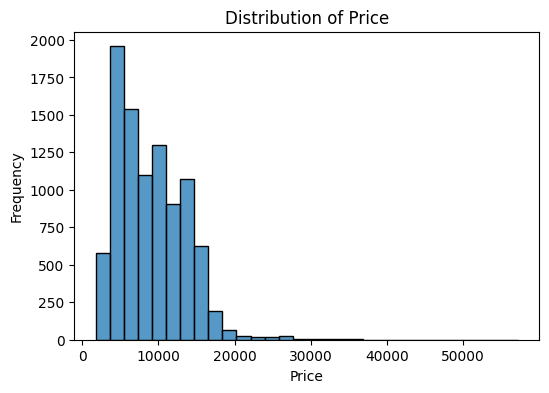

In [30]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'],bins=30)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Obsevation: The price distribution is possitively skewed with a small number of expensive flights forming a long right trail.

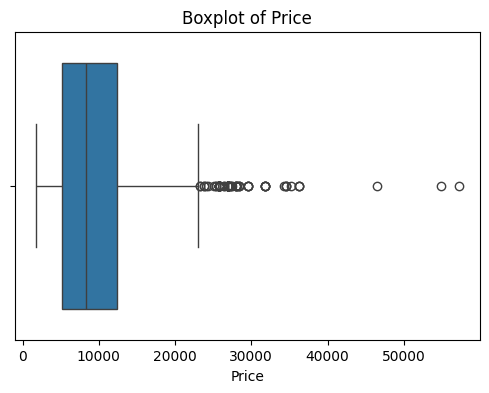

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.show()

Observation: The boxplot indicates several potential outliers. Since these high prices are plausible for flight tickets, they will not be removed at this stage. Their impact on model performance will be evaluated later.

Two preprocessing strategies were created after EDA. Since Dataset P and Dataset Q differ only in their treatment of the Day feature, their overall feature distributions remain nearly identical. Therefore, the exploratory visualizations are presented only once.

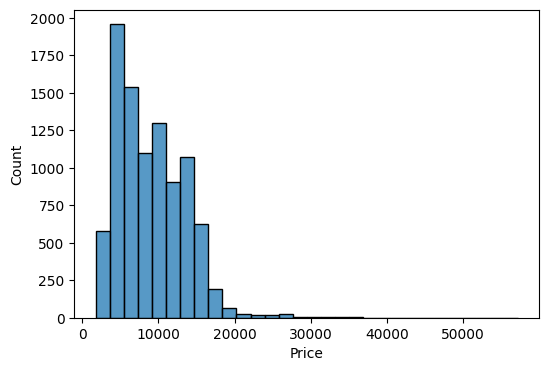

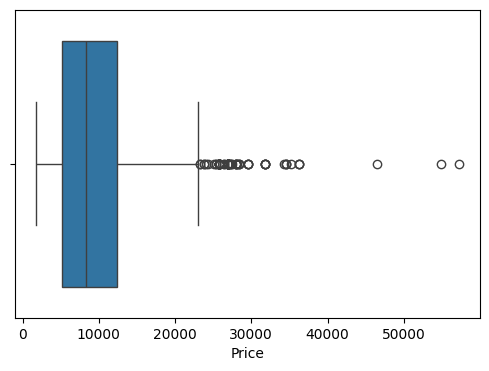

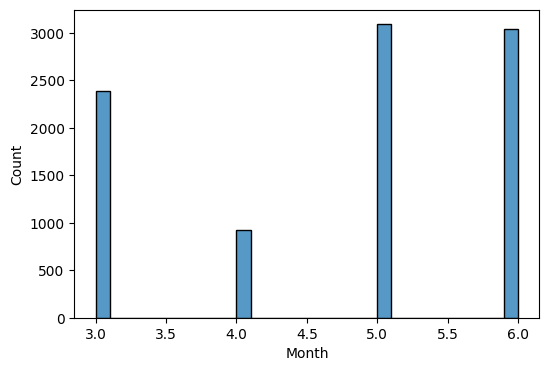

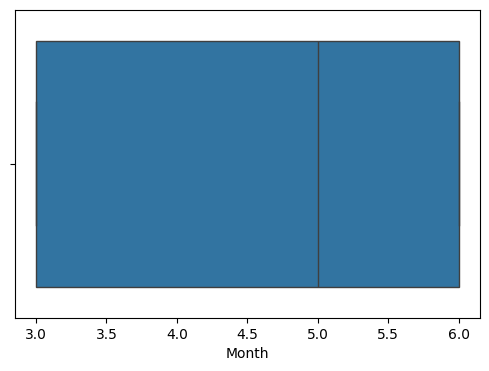

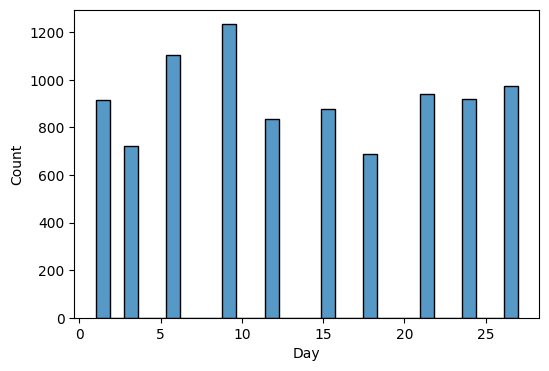

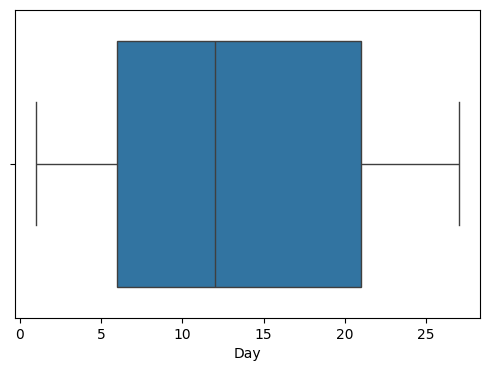

In [32]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],bins=30)
  plt.show()
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[col])
  plt.show()

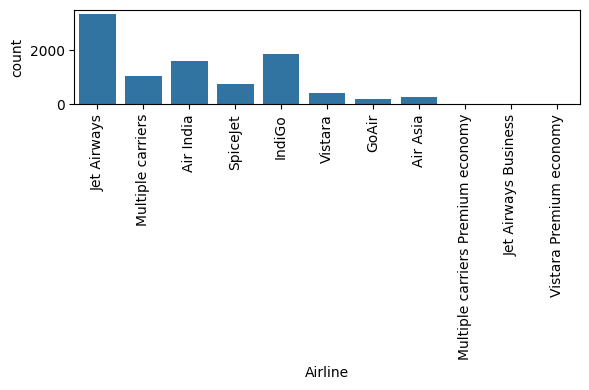

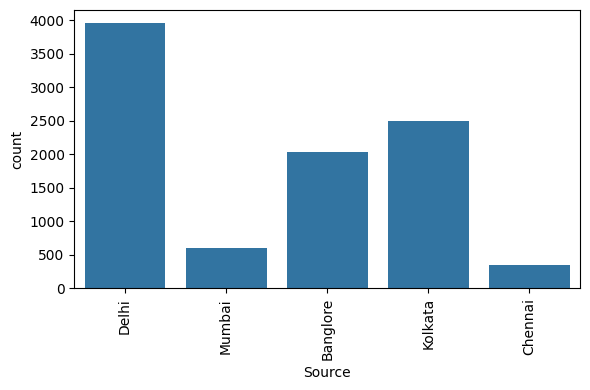

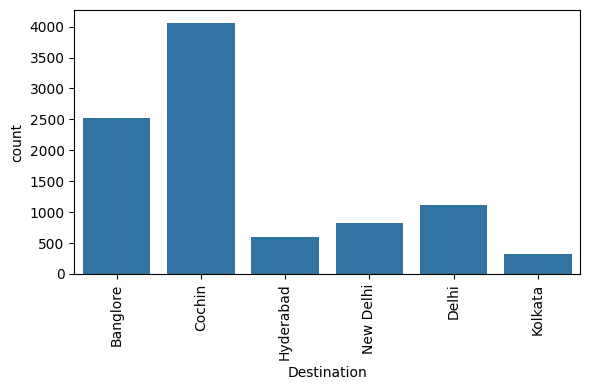

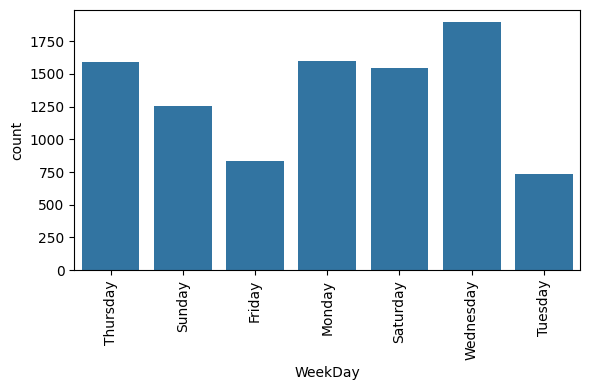

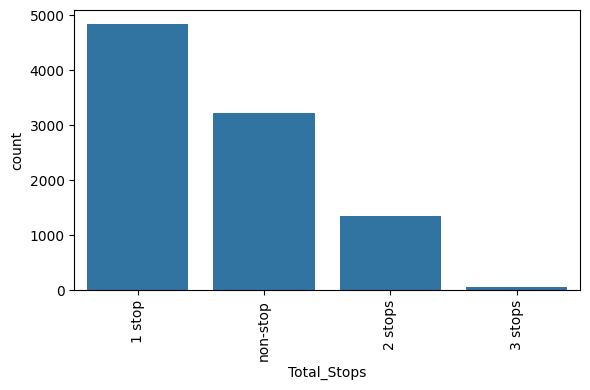

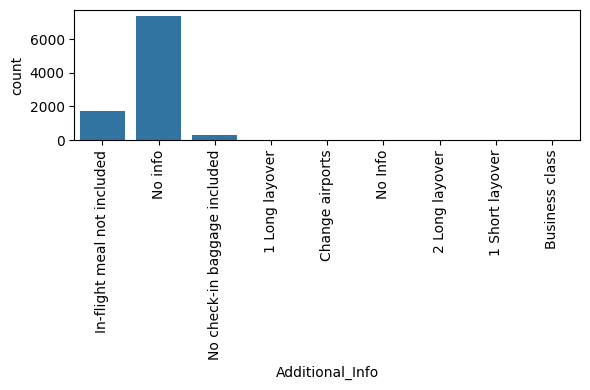

In [33]:
cat_cols1=['Airline','Source','Destination','WeekDay','Total_Stops','Additional_Info']
for col in cat_cols1:
  plt.figure(figsize=(6,4))
  sns.countplot(x=df[col])
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

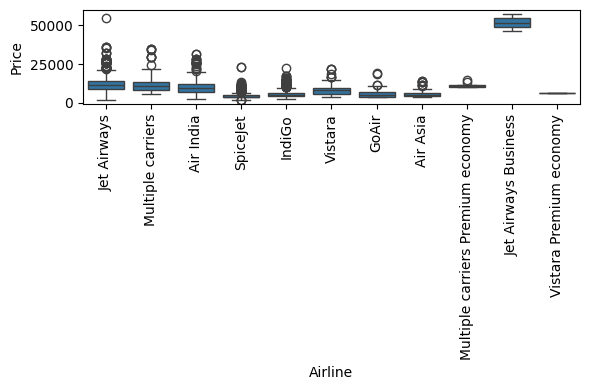

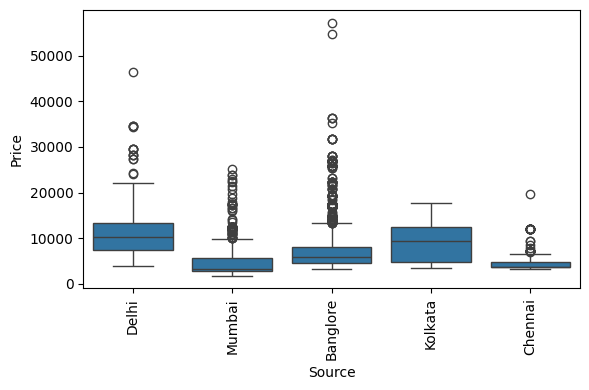

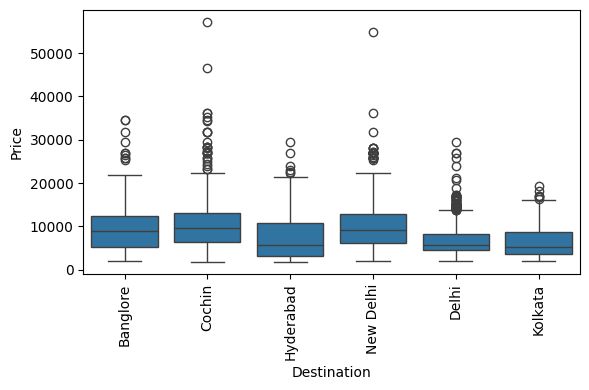

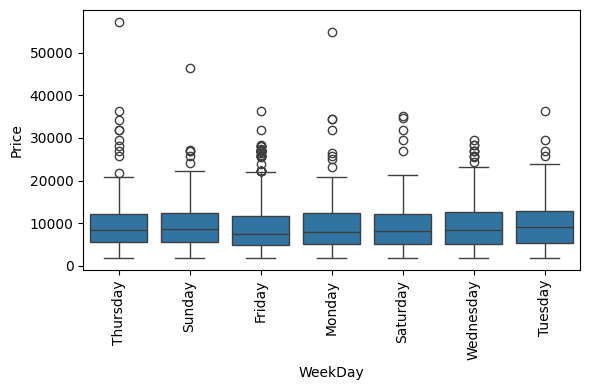

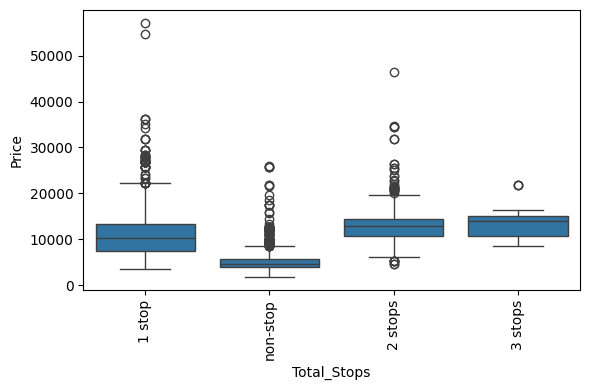

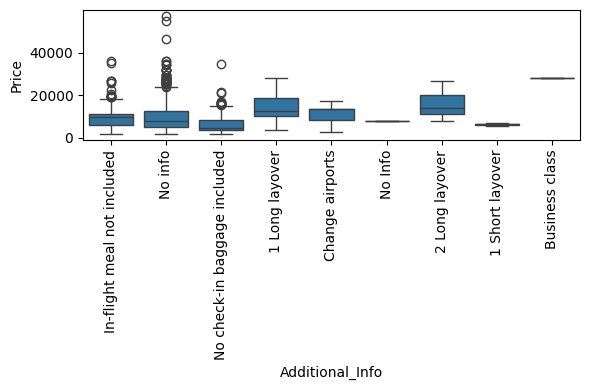

In [34]:
for col in cat_cols1:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=col, y='Price', data=df)
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

The boxplots suggest that Airline, Source, and Total_Stops are the most influential categorical features for predicting flight prices. Destination also contributes, although the differences between its categories are smaller. WeekDay has almost identical price distributions across all categories, indicating that it is likely to be the least useful feature. While Additional_Info appears to affect price, some of its categories have very few observations, so those patterns may not be reliable.

In [35]:
df["Additional_Info"].value_counts(normalize=True)

,proportion
Additional_Info,
No info,0.780400
In-flight meal not included,0.185205
No check-in baggage included,0.031538
1 Long layover,0.001376
Change airports,0.000529
No Info,0.000317
2 Long layover,0.000317
1 Short layover,0.000212
Business class,0.000106


The Additional_Info column is highly imbalanced with around 78% of it being No info. Since it is recorded as valid category in the dataset rather than a missing value, it is retained. Its actual predictive value will be determined later during model evaluation.

In [36]:
def time1(duration):
  minutes=0
  D=duration.split()
  for part in D:
    if "h" in part:
      minutes+=int(part[:-1])*60
    elif "m" in part:
      minutes+=int(part[:-1])
  return minutes

In [37]:
p['Duration_in_minutes']=p['Duration'].apply(time1)
q['Duration_in_minutes']=q['Duration'].apply(time1)

In [38]:
p.drop('Duration',axis=1,inplace=True)
q.drop('Duration',axis=1,inplace=True)

In [39]:
def time2(time):
  part=time.split(':')
  hour=int(part[0])
  m=part[1]
  n=m.split()
  minute=int(n[0])
  return hour, minute

In [40]:
p[['Arrival_Hour','Arrival_Min']]=p['Arrival_Time'].apply(time2).apply(pd.Series)
q[['Arrival_Hour','Arrival_Min']]=q['Arrival_Time'].apply(time2).apply(pd.Series)

In [41]:
p[['Dep_Hour','Dep_Min']]=p['Dep_Time'].apply(time2).apply(pd.Series)
q[['Dep_Hour','Dep_Min']]=q['Dep_Time'].apply(time2).apply(pd.Series)

In [42]:
p.drop(['Arrival_Time','Dep_Time'],axis=1,inplace=True)
q.drop(['Arrival_Time','Dep_Time'],axis=1,inplace=True)

In [43]:
p[['Source','Destination','Total_Stops','Route']].sample(20)

,Source,Destination,Total_Stops,Route
5925,Delhi,Cochin,2 stops,DEL → GOI → BOM → COK
1008,Kolkata,Cochin,1 stop,CCU → BOM → BLR
2829,Mumbai,Cochin,non-stop,BOM → HYD
2876,Mumbai,Hyderabad,non-stop,BOM → HYD
271,Banglore,Banglore,non-stop,BLR → DEL
8744,Kolkata,Delhi,1 stop,CCU → DEL → BLR
1491,Kolkata,Delhi,1 stop,CCU → GAU → BLR
7042,Delhi,Cochin,1 stop,DEL → HYD → COK
8759,Delhi,Cochin,1 stop,DEL → BOM → COK
6840,Delhi,Delhi,1 stop,DEL → BLR → COK


In [44]:
p.loc[(p['Source']=='Delhi')&(p['Destination']=='Cochin')&(p['Total_Stops']=='2 stops'),'Route'].value_counts()
p.groupby(['Source','Destination','Total_Stops'])['Route'].nunique()

Source    Destination  Total_Stops
Banglore  Banglore     1 stop          8
                       2 stops         5
                       3 stops         1
                       non-stop        1
          Cochin       1 stop         12
                                      ..
Mumbai    Hyderabad    1 stop          5
                       2 stops         9
                       non-stop        1
          Kolkata      1 stop          1
                       non-stop        1
Name: Route, Length: 72, dtype: int64

In [45]:
p.drop('Route',axis=1,inplace=True)
q.drop('Route',axis=1,inplace=True)

The Route column contains a large number of unique values, making one-hot encoding impractical. Since its most informative aspect was already captured through Total_Stops, the Route column was dropped before model training.

In [46]:
p['Total_Stops']=p['Total_Stops'].replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}).astype(int)
q['Total_Stops']=q['Total_Stops'].replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}).astype(int)

/tmp/ipykernel_1574/3216849183.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  p['Total_Stops']=p['Total_Stops'].replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}).astype(int)
/tmp/ipykernel_1574/3216849183.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  q['Total_Stops']=q['Total_Stops'].replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}).astype(int)


In [47]:
X_p=p.drop('Price',axis=1)
y_p=p['Price']
X_q=q.drop('Price',axis=1)
y_q=q['Price']

In [48]:
from sklearn.model_selection import train_test_split
X_train_p,X_test_p,y_train_p,y_test_p=train_test_split(X_p,y_p,test_size=0.3,random_state=42)
X_train_q,X_test_q,y_train_q,y_test_q=train_test_split(X_q,y_q,test_size=0.3,random_state=42)

In [49]:
cat_cols=['Source','Destination','Airline','WeekDay','Additional_Info']
from sklearn.preprocessing import OneHotEncoder
encoder_p=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder_q=OneHotEncoder(handle_unknown='ignore',sparse_output=False)

In [50]:
from sklearn.compose import ColumnTransformer
preprocessor_p=ColumnTransformer(transformers=[('cat',encoder_p,cat_cols)],remainder='passthrough')
preprocessor_q=ColumnTransformer(transformers=[('cat',encoder_q,cat_cols)],remainder='passthrough')

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
lr_pipeline_p=Pipeline([('preprocessor',preprocessor_p),('model',LinearRegression())])
lr_pipeline_q=Pipeline([('preprocessor',preprocessor_q),('model',LinearRegression())])

In [52]:
lr_pipeline_p.fit(X_train_p,y_train_p)
lr_y_pred_p=lr_pipeline_p.predict(X_test_p)
lr_pipeline_q.fit(X_train_q,y_train_q)
lr_y_pred_q=lr_pipeline_q.predict(X_test_q)

In [53]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
lr_r2_p=r2_score(y_test_p,lr_y_pred_p)
lr_r2_q=r2_score(y_test_q,lr_y_pred_q)
lr_mae_p=mean_absolute_error(y_test_p,lr_y_pred_p)
lr_mae_q=mean_absolute_error(y_test_q,lr_y_pred_q)
lr_mse_p=mean_squared_error(y_test_p,lr_y_pred_p)
lr_mse_q=mean_squared_error(lr_y_pred_q,y_test_q)
print('Linear Regression\n\tDataset p\tDataset q\n')
print(f'R2_score: {lr_r2_p}\t {lr_r2_q}')
print(f'MAE: {lr_mae_p}\t{lr_mae_q}\nMSE: {lr_mse_p}\t{lr_mse_q}')

Linear Regression
	Dataset p	Dataset q

R2_score: 0.5922036557680562	 0.5988994168494601
MAE: 1938.5117617883216	1936.877584104866
MSE: 7841393.4595279405	7916708.73235078


In [54]:
from sklearn.tree import DecisionTreeRegressor
dt_pipeline_p=Pipeline([('preprocessor',preprocessor_p),('model',DecisionTreeRegressor())])
dt_pipeline_q=Pipeline([('preprocessor',preprocessor_q),('model',DecisionTreeRegressor())])
dt_pipeline_p.fit(X_train_p,y_train_p)
dt_pipeline_q.fit(X_train_q,y_train_q)
dt_y_pred_p=dt_pipeline_p.predict(X_test_p)
dt_y_pred_q=dt_pipeline_q.predict(X_test_q)

In [55]:
dt_r2_p=r2_score(y_test_p,dt_y_pred_p)
dt_r2_q=r2_score(y_test_q,dt_y_pred_q)
dt_mae_p=mean_absolute_error(y_test_p,dt_y_pred_p)
dt_mae_q=mean_absolute_error(y_test_q,dt_y_pred_q)
dt_mse_p=mean_squared_error(y_test_p,dt_y_pred_p)
dt_mse_q=mean_squared_error(y_test_q,dt_y_pred_q)

In [56]:
print('Decision Tree\n\tDataset p\tDataset q\n')
print(f'R2_score: {dt_r2_p}\t {dt_r2_q}\nMAE: {dt_mae_p}\t{dt_mae_q}\nMSE: {dt_mse_p}\t{dt_mse_q}')

Decision Tree
	Dataset p	Dataset q

R2_score: 0.49363203798610245	 0.5205926164549859
MAE: 1748.272427983539	1750.3317655571636
MSE: 9736797.501038603	9462286.46653401


In [57]:
train_pred_p=dt_pipeline_p.predict(X_train_p)
r2s=r2_score(y_train_p,train_pred_p)
print(r2s)

0.9918989058775367


In [58]:
from sklearn.model_selection import GridSearchCV
param_grid={"model__max_depth":[5,10,15,20,None],"model__min_samples_split":[2,5,10],"model__min_samples_leaf":[1,2,4]}
grid_p=GridSearchCV(dt_pipeline_p,param_grid,cv=5,n_jobs=-1,scoring="r2")
grid_p.fit(X_train_p,y_train_p)
grid_q=GridSearchCV(dt_pipeline_q,param_grid,cv=5,scoring="r2",n_jobs=-1)
grid_q.fit(X_train_q,y_train_q)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Source',
                                                                          'Destination',
                                                                          'Airline',
                                                                          'WeekDay',
                                                                          'Additional_Info'])])),
                                       ('model', DecisionTreeRegressor())]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, 20, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [59]:
print(grid_p.best_params_)
print(grid_p.best_score_)
print(grid_q.best_params_)
print(grid_q.best_score_)

{'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}
0.596376357385797
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}
0.6067853342101939


In [60]:
best_dt_p=grid_p.best_estimator_
best_dt_q=grid_q.best_estimator_
best_dt_y_pred_p=best_dt_p.predict(X_test_p)
best_dt_y_pred_q=best_dt_q.predict(X_test_q)
best_dt_r2_p=r2_score(y_test_p,best_dt_y_pred_p)
best_dt_r2_q=r2_score(y_test_q,best_dt_y_pred_q)
best_dt_mae_p=mean_absolute_error(y_test_p,best_dt_y_pred_p)
best_dt_mae_q=mean_absolute_error(y_test_q,best_dt_y_pred_q)
best_dt_mse_p=mean_squared_error(y_test_p,best_dt_y_pred_p)
best_dt_mse_q=mean_squared_error(y_test_q,best_dt_y_pred_q)

In [61]:
print('Decision Tree\n\tDataset p\tDataset q\n')
print(f'R2_score: {best_dt_r2_p}\t {best_dt_r2_q}\nMAE: {best_dt_mae_p}\t{best_dt_mae_q}\nMSE: {best_dt_mse_p}\t{best_dt_mse_q}')

Decision Tree
	Dataset p	Dataset q

R2_score: 0.6509733750148732	 0.5990122948388312
MAE: 1801.6490477999307	1734.789971802466
MSE: 6711328.174150657	7914480.806983218


In [62]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline_p=Pipeline([('preprocessor',preprocessor_p),('model',RandomForestRegressor(random_state=42))])
rf_pipeline_q=Pipeline([('preprocessor',preprocessor_q),('model',RandomForestRegressor(random_state=42))])
rf_pipeline_p.fit(X_train_p,y_train_p)
rf_pipeline_q.fit(X_train_q,y_train_q)
rf_y_pred_p=rf_pipeline_p.predict(X_test_p)
rf_y_pred_q=rf_pipeline_q.predict(X_test_q)

In [63]:
rf_r2_p=r2_score(y_test_p,rf_y_pred_p)
rf_r2_q=r2_score(y_test_q,rf_y_pred_q)
rf_mae_p=mean_absolute_error(y_test_p,rf_y_pred_p)
rf_mae_q=mean_absolute_error(y_test_q,rf_y_pred_q)
rf_mse_p=mean_squared_error(y_test_p,rf_y_pred_p)
rf_mse_q=mean_squared_error(y_test_q,rf_y_pred_q)
print('Random Forest\n\tDataset p\tDataset q\n')
print(f'R2_score: {rf_r2_p}\t {rf_r2_q}\nMAE: {rf_mae_p}\t{rf_mae_q}\nMSE: {rf_mse_p}\t{rf_mse_q}')

Random Forest
	Dataset p	Dataset q

R2_score: 0.7297038404845374	 0.7188764154723002
MAE: 1413.9058865359314	1442.3171931465783
MSE: 5197443.693008083	5548666.917955832


In [64]:
param_grid={'model__n_estimators':[100,200,300],
            'model__max_depth':[5,10,15,20,None],
            'model__min_samples_split':[2,5,10],
            'model__min_samples_leaf':[1,2,5,10]}

In [68]:
grid_rf_p=GridSearchCV(rf_pipeline_p,param_grid,cv=5,scoring='r2',n_jobs=-1)
grid_rf_q=GridSearchCV(rf_pipeline_q,param_grid,cv=5,scoring='r2',n_jobs=-1)
grid_rf_p.fit(X_train_p,y_train_p)
grid_rf_q.fit(X_train_q,y_train_q)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['Source',
                                                                          'Destination',
                                                                          'Airline',
                                                                          'WeekDay',
                                                                          'Additional_Info'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, 15, 20, None],
                         'model__min_samples_leaf': [1, 2, 5, 10],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='r2')

In [69]:
print(grid_rf_p.best_params_)
print(grid_rf_p.best_score_)
print(grid_rf_q.best_params_)
print(grid_rf_q.best_score_)

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 100}
0.659319381890558
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}
0.6885976940773542


In [70]:
best_rf_p=grid_rf_p.best_estimator_
best_rf_q=grid_rf_q.best_estimator_
best_rf_y_pred_p=best_rf_p.predict(X_test_p)
best_rf_y_pred_q=best_rf_q.predict(X_test_q)
best_rf_r2_p=r2_score(y_test_p,best_rf_y_pred_p)
best_rf_r2_q=r2_score(y_test_q,best_rf_y_pred_q)
best_rf_mae_p=mean_absolute_error(y_test_p,best_rf_y_pred_p)
best_rf_mae_q=mean_absolute_error(y_test_q,best_rf_y_pred_q)
best_rf_mse_p=mean_squared_error(y_test_p,best_rf_y_pred_p)
best_rf_mse_q=mean_squared_error(y_test_q,best_rf_y_pred_q)
print('Random Forest\n\tDataset p\tDataset q\n')
print(f'R2_score: {best_rf_r2_p}\t {best_rf_r2_q}\nMAE: {best_rf_mae_p}\t{best_rf_mae_q}\nMSE: {best_rf_mse_p}\t{best_rf_mse_q}')

Random Forest
	Dataset p	Dataset q

R2_score: 0.7365492432372254	 0.716599001967894
MAE: 1420.6157980157275	1460.6191514708187
MSE: 5065815.498856759	5593617.28735168


In [71]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Dataset P R²": [
        lr_r2_p,
        dt_r2_p,
        best_dt_r2_p,
        rf_r2_p,
        best_rf_r2_p
    ],
    "Dataset Q R²": [
        lr_r2_q,
        dt_r2_q,
        best_dt_r2_q,
        rf_r2_q,
        best_rf_r2_q
    ],
    "Dataset P MAE": [
        lr_mae_p,
        dt_mae_p,
        best_dt_mae_p,
        rf_mae_p,
        best_rf_mae_p
    ],
    "Dataset Q MAE": [
        lr_mae_q,
        dt_mae_q,
        best_dt_mae_q,
        rf_mae_q,
        best_rf_mae_q
    ],
    "Dataset P MSE": [
        lr_mse_p,
        dt_mse_p,
        best_dt_mse_p,
        rf_mse_p,
        best_rf_mse_p
    ],
    "Dataset Q MSE": [
        lr_mse_q,
        dt_mse_q,
        best_dt_mse_q,
        rf_mse_q,
        best_rf_mse_q
    ]
})


In [72]:
comparison["Better dataset"]=comparison.apply(lambda row:"P" if row["Dataset P R²"] > row["Dataset Q R²"] else "Q",
    axis=1 )
comparison

,Model,Dataset P R²,Dataset Q R²,Dataset P MAE,Dataset Q MAE,Dataset P MSE,Dataset Q MSE,Better dataset
0,Linear Regression,0.592204,0.598899,1938.511762,1936.877584,7.841393e+06,7.916709e+06,Q
1,Decision Tree,0.493632,0.520593,1748.272428,1750.331766,9.736798e+06,9.462286e+06,Q
2,Tuned Decision Tree,0.650973,0.599012,1801.649048,1734.789972,6.711328e+06,7.914481e+06,P
3,Random Forest,0.729704,0.718876,1413.905887,1442.317193,5.197444e+06,5.548667e+06,P
4,Tuned Random Forest,0.736549,0.716599,1420.615798,1460.619151,5.065815e+06,5.593617e+06,P


Conclusion

Three regression models were evaluated on two preprocessing strategies for flight price prediction. Dataset P excluded the Day feature, while Dataset Q retained it by removing rows with missing values.

Linear Regression showed the lowest performance, while the Decision Tree initially overfit but improved after hyperparameter tuning but remained inferior to Random Forest. The tuned Random Forest trained on Dataset P achieved the best performance with an R² score of approximately 0.737, making it the final selected model.

Overall, Dataset P consistently matched or outperformed Dataset Q, indicating that retaining more training data by dropping the Day feature was more effective than removing incomplete rows.

This project demonstrates that thoughtful preprocessing, feature engineering, and ensemble methods can effectively predict flight prices. While the final model explains about 74% of the variance in ticket prices, further improvements may be achieved through richer features and more advanced models.

In [73]:
feature_names=best_rf_p.named_steps['preprocessor'].get_feature_names_out()
importance=pd.DataFrame({'Feature':feature_names,'Importance':best_rf_p.named_steps['model'].feature_importances_})
importance=importance.sort_values(by='Importance',ascending=False)
importance['Feature']=importance['Feature'].str.replace('cat__','',regex=False).str.replace('remainder__','',regex=False)

In [74]:
importance

,Feature,Importance
34,Total_Stops,0.489448
14,Airline_Jet Airways,0.069446
36,Duration_in_minutes,0.059965
37,Arrival_Hour,0.044313
38,Arrival_Min,0.040590
39,Dep_Hour,0.027934
15,Airline_Jet Airways Business,0.027841
16,Airline_Multiple carriers,0.027627
13,Airline_IndiGo,0.026401
35,Month,0.020534


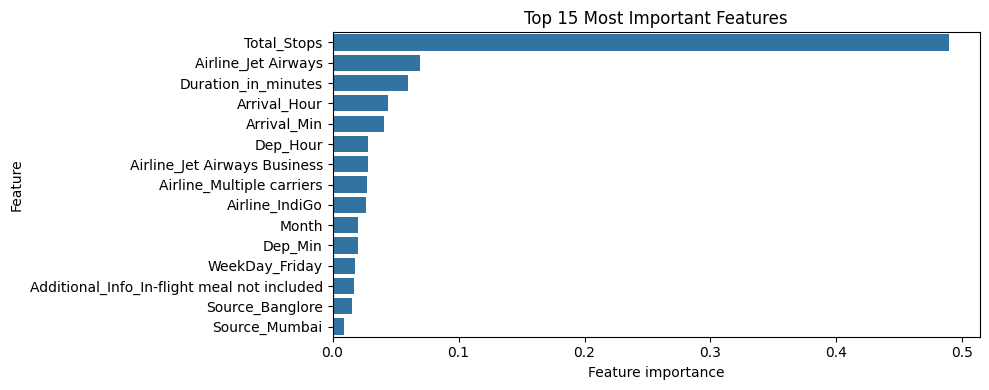

In [75]:
top_features=importance.head(15)
plt.figure(figsize=(10,4))
sns.barplot(data=top_features,x='Importance',y='Feature')
plt.title('Top 15 Most Important Features')
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Feature importance shows that Total_Stops is by far the most influential feature for predicting flight prices. Airline, flight duration, and departure/arrival timings also contribute significantly, whereas calendar-related features such as Month and WeekDay have relatively low importance. This indicates that journey characteristics have a greater impact on ticket prices than the date of travel.

In [76]:
import shap
explainer=shap.TreeExplainer(best_rf_p.named_steps['model'])
X_test_processed=best_rf_p.named_steps['preprocessor'].transform(X_test_p)
shap_values=explainer.shap_values(X_test_processed)

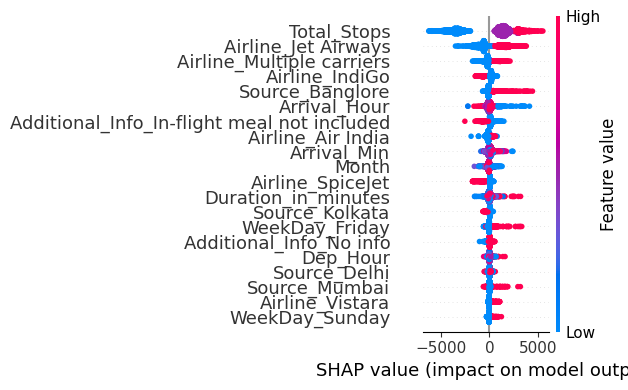

In [77]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=importance["Feature"],
    plot_size=(6,4),
    show=False
)

fig = plt.gcf()
fig.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

The SHAP summary plot shows that Total_Stops has the strongest impact on flight price predictions, followed by airline, duration, and time-related features. The distribution of SHAP values explains how individual features increase or decrease the predicted ticket price, making the Random Forest model more interpretable. The results are consistent with the Feature Importance analysis.

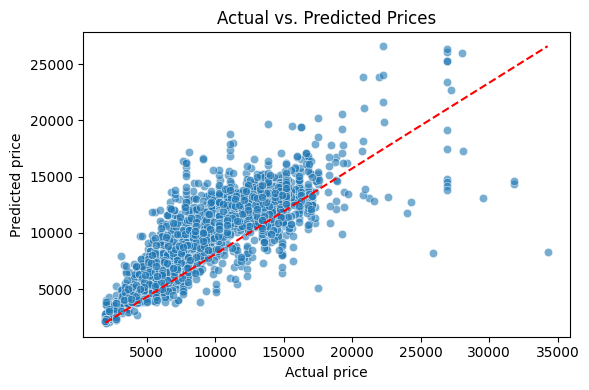

In [78]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test_p,y=best_rf_y_pred_p,alpha=0.6)
plt.plot([y_test_p.min(),y_test_p.max()],[best_rf_y_pred_p.min(),best_rf_y_pred_p.max()],color='red',linestyle='--')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual vs. Predicted Prices')
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

The Actual vs Predicted plot shows a strong positive relationship between the predicted and actual flight prices. Most observations lie close to the ideal prediction line, indicating that the tuned Random Forest model predicts typical ticket prices accurately. Larger deviations are observed for some high-priced flights, suggesting that these less frequent cases are more difficult for the model to predict.

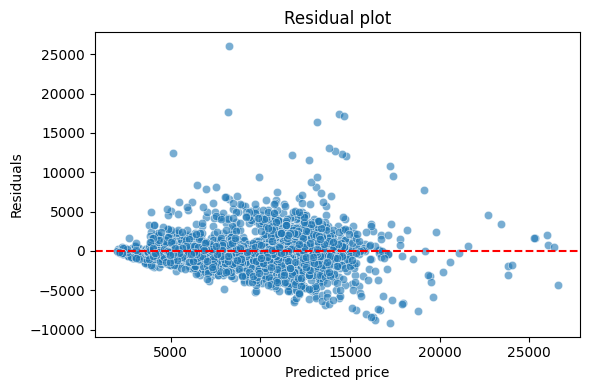

In [79]:
residuals=y_test_p-best_rf_y_pred_p
plt.figure(figsize=(6,4))
sns.scatterplot(x=best_rf_y_pred_p,y=residuals,alpha=0.6)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Predicted price')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

The residual plot shows that the prediction errors are centered around zero with no clear systematic pattern, indicating that the Random Forest model provides an unbiased fit. Although the variability of residuals increases slightly for higher-priced flights, the overall random distribution suggests that the model captures the underlying relationship reasonably well.

In [80]:
import joblib
joblib.dump(best_rf_p,'flight_price_model.pkl')

['flight_price_model.pkl']

In [81]:
importance.to_csv('feature_importance.csv',index=False)

In [82]:
import os
os.getcwd()
os.listdir()

['.config',
 'feature_importance.csv',
 'actual_vs_predicted.png',
 'residual_plot.png',
 'flight_price_model.pkl',
 'flight_price.csv',
 'shap_summary.png',
 'feature_importance.png',
 'sample_data']